# FEM Pendulum Test Cases (2 s each)

This notebook sets up a consistent FEM pendulum configuration and runs:
1) Free swing
2) Constant torque from `theta = 0` with gravity **off**
3) Constant torque from `theta = 0` with gravity **on**
4) Wall impact

All cases run for **2 s**.


## Imports


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum.components import FEMPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config


## General FEM Configuration

We define a reusable configuration block to ensure all scenarios are comparable.


In [11]:
def build_fem_config(
    theta0_deg=0.0,
    omega0=0.0,
    drive_torque=0.0,
    with_contact=False,
    use_gravity=True,
    t_end=2.0,
    dt=0.01,
    animate=False,
):
    geom_params = config.GeometryParameters()

    mesh_params = config.MeshParameters()
    mesh_params.max_element_size = geom_params.r_rod / 3

    init_params = config.InitialConditionParameters()
    init_params.angular_position_deg = theta0_deg
    init_params.angular_velocity = omega0
    init_params.drive_torque = drive_torque

    sim_params = config.SimulationParameters()
    sim_params.tau = dt
    sim_params.t_end = t_end
    sim_params.with_contact = with_contact
    sim_params.use_gravity = use_gravity

    anim_params = config.AnimationParameters()
    anim_params.animate = animate

    return mesh_params, init_params, sim_params, anim_params


def init_fem(theta0_deg=0.0, omega0=0.0, drive_torque=0.0, with_contact=False, use_gravity=True, dt=0.01):
    mesh_params, init_params, sim_params, anim_params = build_fem_config(
        theta0_deg=theta0_deg,
        omega0=omega0,
        drive_torque=drive_torque,
        with_contact=with_contact,
        use_gravity=use_gravity,
        t_end=2.0,
        dt=dt,
        animate=False,
    )

    fem = FEMPendulum(name="FEM_Pendulum", group="Plant")
    fem.set_parameters(
        init_params=init_params,
        sim_params=sim_params,
        anim_params=anim_params,
        mesh_params=mesh_params,
    )
    fem.initialize(0.0)
    return fem, sim_params


def run_case(fem, sim_params, torque_fn=None):
    t = 0.0
    dt = sim_params.tau
    t_end = sim_params.t_end

    while t < t_end:
        torque = 0.0 if torque_fn is None else torque_fn(t)
        fem.set_inputs({"tau": torque}, t=t)
        fem.do_step(t, dt)
        t += dt

    return fem.get_history()


def plot_theta(history, title):
    t_vals = history["theta"]["time"]
    theta_vals = history["theta"]["values"]
    plt.figure(figsize=(8, 4))
    plt.plot(t_vals, np.rad2deg(theta_vals), label="FEM")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Theta (deg)")
    plt.grid()
    plt.show()


## Case 1: Free Swing (gravity on, zero torque)


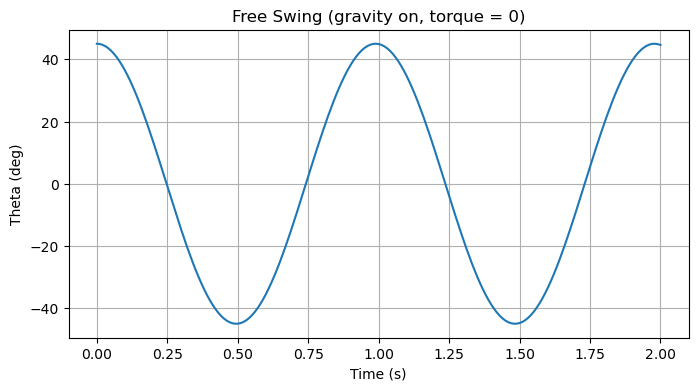

In [12]:
fem, sim_params = init_fem(theta0_deg=45.0, omega0=0.0, drive_torque=0.0, use_gravity=True, with_contact=False, dt=0.01)

hist_free = run_case(fem, sim_params)
plot_theta(hist_free, "Free Swing (gravity on, torque = 0)")


## Case 2: Constant Torque (gravity off, theta = 0)


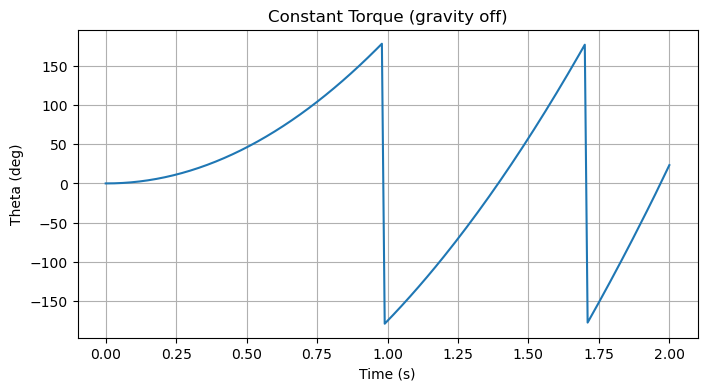

In [ ]:
fem, sim_params = init_fem(theta0_deg=0.0, omega0=0.0, drive_torque=0.0, use_gravity=False, with_contact=False, dt=0.01)

const_tau = 0.2
hist_const_off = run_case(fem, sim_params, torque_fn=lambda t: const_tau)
plot_theta(hist_const_off, "Constant Torque (gravity off)")


## Case 3: Constant Torque (gravity on, theta = 0)


In [ ]:
fem, sim_params = init_fem(theta0_deg=0.0, omega0=0.0, drive_torque=0.0, use_gravity=True, with_contact=False, dt=0.01)

const_tau = 0.2
hist_const_on = run_case(fem, sim_params, torque_fn=lambda t: const_tau)
plot_theta(hist_const_on, "Constant Torque (gravity on)")


## Case 4: Wall Impact (contact enabled)

We start with a non-zero initial angle to induce impact.


In [ ]:
fem, sim_params = init_fem(theta0_deg=30.0, omega0=0.0, drive_torque=0.0, use_gravity=True, with_contact=True, dt=0.01)

hist_contact = run_case(fem, sim_params)
plot_theta(hist_contact, "Wall Impact (contact enabled)")
